# Анализ лояльности пользователей Яндекс Афиши

Автор: Анастасия Хайрутдинова

Дата: 10.06.2026

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.


In [1]:
!pip install sqlalchemy 

In [2]:
!pip install psycopg2-binary 

In [226]:
!pip install python-dotenv

In [3]:
import pandas as pd
from sqlalchemy import create_engine 
import os
from dotenv import load_dotenv

In [ ]:
#пароли убраны в .env
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')}

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

In [5]:
engine = create_engine(connection_string) 

In [6]:
query = '''SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.created_dt_msk::date
        - LAG(p.created_dt_msk::date) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_dt_msk
        ) AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e
    ON p.event_id = e.event_id
LEFT JOIN afisha.city AS c
    ON e.city_id = c.city_id
LEFT JOIN afisha.regions AS r
    ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main <> 'фильм'
ORDER BY p.user_id'''

In [7]:
df = pd.read_sql_query(query, con=engine) 

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [8]:
#выводим информацию о выгруженном дата фрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  region_name            290611 non-null  obje

In [9]:
df['days_since_prev'].isna().sum()

21933

***Промежуточный вывод***

В результате SQL-запроса выгружен датафрейм с размером **290 611 строк и 14 столбцов**. Данные содержат информацию о пользователях, заказах, мероприятиях и местах их проведения.

Типы данных в целом соответствуют содержимому столбцов: даты и время представлены типом `datetime64[ns]`, выручка - типом `float64`, количество билетов и идентификаторы - целочисленными типами, категориальные признаки - типом `object`.

Пропущенные значения обнаружены только в столбце `days_since_prev`: заполнено 268 678 значений из 290 611. Такие пропуски ожидаемы, поскольку для первой покупки пользователя невозможно рассчитать количество дней с предыдущего заказа.

На этапе предобработки можно выполнить небольшие корректировки, например:
- привести `days_since_prev` к целочисленному типу с поддержкой пропусков (`Int64`), тогда кака сейчас это тип `float64`;
- проверить категориальные признаки на некорректные значения;
- изучить числовые показатели, в первую очередь `revenue` и `tickets_count`, на наличие аномалий и выбросов;
- при необходимости оптимизировать типы числовых данных (однако сейчас типы данных выглядят приемлемо).

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [10]:
!pip install phik

     |████████████████████████████████| 677 kB 2.2 MB/s eta 0:00:01


In [11]:
#импортируем все необходимые библиотеки для работы далее
from phik import phik_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
#импортируем датасет с информацией о курсе валют
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [13]:
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [14]:
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Придется объединять таблицы с заказами в тенге по дате, т.к. курс валют ежедневно меняется. То есть нужно соединить даты заказов из начального датасета с курсов валют из tenge_df.

In [15]:
#приведем дату из date колонки к типу дата 
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

In [16]:
#соединяем эту таблицу с основной 
df = df.merge(tenge_df[['data', 'nominal', 'curs']],left_on='order_dt',right_on='data',how='left')

In [17]:
#переводим тенге в рубли по курсу, создадим ревеню в рублях - новый столбец, находим все заказы в тенге и меняем только их
df['revenue_rub'] = df['revenue']
teng = df['currency_code'].str.lower() == 'kzt' #делаем логическое условие для любого написания 
df.loc[teng, 'revenue_rub'] = (df.loc[teng, 'revenue']/ df.loc[teng, 'nominal']* df.loc[teng, 'curs'])

In [18]:
#проверим, что все получилось
df[df['currency_code'].str.lower() == 'kzt'][['currency_code', 'revenue', 'revenue_rub']].head(5)

,currency_code,revenue,revenue_rub
70,kzt,518.10,98.503762
89,kzt,347.18,65.731589
96,kzt,328.77,61.148261
277,kzt,22021.55,4380.702898
460,kzt,7397.66,1478.296591


In [19]:
#теперь удалим ненужные колонки 
df = df.drop(columns=['data', 'nominal', 'curs'])

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Выше в разделе 1.2 уже проверялось, что пропуски имеются только в 1 столбце. Выведем процент пропусков от общего колоичества данных:

In [20]:
missing = pd.DataFrame({'missing_count': df.isna().sum(),'missing_percent': round(df.isna().mean() * 100,1)})
missing

,missing_count,missing_percent
user_id,0,0.0
device_type_canonical,0,0.0
order_id,0,0.0
order_dt,0,0.0
order_ts,0,0.0
currency_code,0,0.0
revenue,0,0.0
tickets_count,0,0.0
days_since_prev,21933,7.5
event_id,0,0.0


Пропуски присутсвуют только в столбце `days_since_prev`, что ожидаемо, количество пропусков - 7.5% от общего числа значений.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  region_name            290611 non-null  obje

Данные с датой и временем представлвены в формате `datetime64[ns]`, что стандартно и удобно. В целом, можно привести столбец только с датой заказа к типу с меньшей точностью\дате, но смысла в этом немного, удобнее работать дальше с форматом `datetime64[ns]` (через .dt). 

В массиве данных можно преобразовать `days_since_prev` из типа  `float64` в тип `Int16`, который будет поддерживать нулевые значения.

Также необходимо проверить диапазоны остальных числовых стлбцов, чтобы определить возможность уменьшения их размерности без потери данных.

In [22]:
df['days_since_prev'].max()

148.0

In [23]:
df['days_since_prev'] = df['days_since_prev'].astype('Int16')

In [24]:
#только для "числовых" типов смотрим разброс по значениям, чтобы понять стоит ли что-то даунгрейдить
df.select_dtypes(include='number').agg(['min', 'max'])

,order_id,revenue,tickets_count,days_since_prev,event_id,revenue_rub
min,1,-90.76,1,0,4436,-90.76
max,8653108,81174.54,57,148,592325,81174.54


In [25]:
df['order_id'] = df['order_id'].astype('int32')
df['tickets_count'] = df['tickets_count'].astype('int8')
df['event_id'] = df['event_id'].astype('int32')

In [26]:
#проверяем
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int16         
 9   event_id               290611 non-null  int32         
 10  service_name           290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  region_name            290611 non-null  obje

После изучения диапазонов числовых значений была уменьшена размерность столбцов без потери информации:

- `order_id` и `event_id` приведены к типу `int32`;
- `tickets_count` приведён к типу `int8`, поскольку максимальное количество билетов в заказе составляет 57;
- `days_since_prev` приведён к типу `Int16`: максимальное значение составляет 148 дней, а использование NaN-типа позволяет сохранить пропуски для первых заказов пользователей.

Столбцы `revenue` и `revenue_rub` оставлены в формате `float64`, поскольку они содержат денежные значения и для дальнейших расчётов желательно сохранить их точность.

При первичном изучении числовых данных также обнаружены отрицательные значения выручки. Скорее всего это возвраты, но это необходимо проверить на следующем этапе.

In [27]:
categorical_cols = [
    'device_type_canonical',
    'currency_code',
    'service_name',
    'event_type_main',
    'region_name',
    'city_name'
]

Теперь проверим столбцы с номинальными данными. Из SQL выгрузки мы выгрузили датасет с ограничение по типу устройства (десктоп и мобильный), валюта оплаты также была проверена в SQL. Возможные аномалии могут присутсвовать в столбцах `service_name`, `event_type_main`, `region_name`, `city_name`

In [28]:
df['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

In [29]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [30]:
df['region_name'].unique()

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', 'Лесодальний край', 'Верхоречная область',
       'Горицветская область', 'Речиновская область', 'Травиницкий округ',
       'Сосновская область', 'Серебринская область', 'Травяная область',
       'Каменноярский край', 'Солнечноземская область',
       'Светополянский округ', 'Заречная область', 'Ручейковский край',
       'Глиногорская область', 'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
       'Зоринский регион', 'Берёзовская область', 'Лесостепной край',
       'Малиновая область', 'Синегорский регион', 'Луговая область',
       'Шанырский регион', 'Каменополянский окр

In [31]:
df['city_name'].unique()

array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Серебрянка', 'Островецк', 'Родниковец', 'Дальнесветск',
       'Луговаярово', 'Дальнополин', 'Ягодиновка', 'Солчелуг', 'Озёрчане',
       'Серебровино', 'Лесоярово', 'Глинополье', 'Глиноград',
       'Дальнесветин', 'Северополье', 'Теплоозеро', 'Горнодолинск',
       'Ордакент', 'Озёрово', 'Луговинск', 'Лугоград', 'Златопольск',
       'Крутовинск', 'Сарыжар', 'Сосновечин', 'Тихоярск', 'Яблонецк',
       'Жаркентай', 'Широковка', 'Синеводов', 'Синеводск', 'Тихосветск',
       'Радужанов', 'Глиногорь', 'Каменосветск', 'Родниковск',
       'Травогород', 'Глинянск', 'Радужинск', 'Поляногорье',
       'Дальнолесье', 'Ручейник', 'Ключеград', 'Ключеводск', 'Поленовино',
       'Речичанск', 'Ключевополье', 'Шаныртау', 'Дальнесоснов'

Данные выглядят нормальными, категорий, которые можно было бы отнести к "нулевым" нет, за исключением значения `другое` в столбце `event_type_main`, что возможно является собирательным словом для отсутсвия категории эвента. Нормализация не требуется.

In [32]:
#теперь перейдем к числовым данным и выбросам. выручка с заказа (revenue_rub) и количество билетов в заказе (tickets_count)
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571987,2.754311
std,875.498172,1.170620
min,-90.760000,1.000000
25%,113.970000,2.000000
50%,351.140000,3.000000
75%,802.050000,4.000000
max,81174.540000,57.000000


In [33]:
df['revenue_rub'].quantile([0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 1])

0.01        0.000000
0.25      113.970000
0.50      351.140000
0.75      802.050000
0.95     1630.650000
0.99     2628.421739
1.00    81174.540000
Name: revenue_rub, dtype: float64

In [34]:
df['tickets_count'].quantile([0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 1])

0.01     1.0
0.25     2.0
0.50     3.0
0.75     4.0
0.95     5.0
0.99     6.0
1.00    57.0
Name: tickets_count, dtype: float64

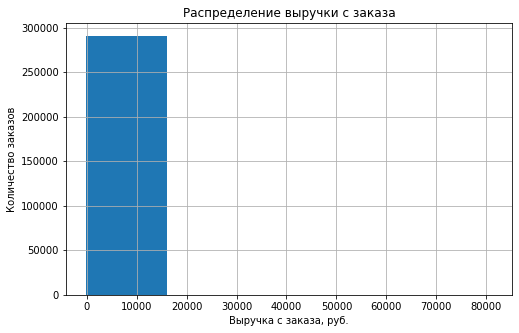

In [35]:
#визуализируем
plt.figure(figsize=(8, 5))
df['revenue_rub'].hist(bins=5)
plt.xlabel('Выручка с заказа, руб.')
plt.ylabel('Количество заказов')
plt.title('Распределение выручки с заказа')
plt.show()

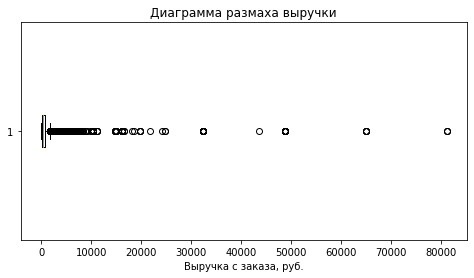

In [36]:
#посмотрим на коробку с усами, чтобы точно убедится в выбросах
plt.figure(figsize=(8, 4))
plt.boxplot(df['revenue_rub'], vert=False)
plt.xlabel('Выручка с заказа, руб.')
plt.title('Диаграмма размаха выручки')
plt.show()

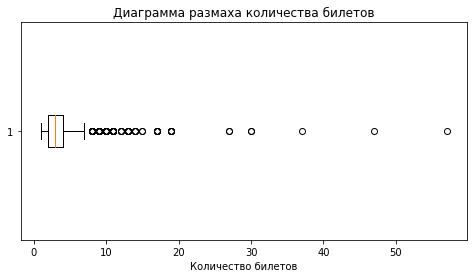

In [37]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['tickets_count'], vert=False)
plt.xlabel('Количество билетов')
plt.title('Диаграмма размаха количества билетов')
plt.show()

Из диаграмм выше видно, что присутсвуют большие выбросы, хвосты графиков сдвинуты. Попробуем отфильтровать по 99-процентилю и посмотреть количество удаленных строк.

In [38]:
#количество строк до удаления и 99-процентиль
rows_before = len(df)
revenue_99 = df['revenue_rub'].quantile(0.99)
revenue_99

2628.4217390400004

In [39]:
#фильтруем
df = df[df['revenue_rub'] <= revenue_99]

In [40]:
#считаем количество удаленных строк и их процент от общего числа
rows_after = len(df)
removed_rows = rows_before-rows_after
removed_t = removed_rows/rows_before*100

print('Строк до фильтрации:', rows_before)
print('Строк после фильтрации:', rows_after)
print('Удалено строк:', removed_rows)
print(f'Доля удалённых строк: {removed_t:.2f}%')

Строк до фильтрации: 290611
Строк после фильтрации: 287786
Удалено строк: 2825
Доля удалённых строк: 0.97%


Выбросы составили меньше 1% процента от всех данных, можно их спокойно удалить, что не скажется на анализе.

Однако, помимо выбросов, присутсвуют еще и заказы с отрицательной выручкой (предположительно возвраты). Отдельно посмотрим, сколько таких заказов, какой процент и что это за заказы.

In [41]:
negative_revenue = df[df['revenue_rub'] < 0]
print('Количество заказов с отрицательной выручкой:', len(negative_revenue))
print(f'Доля: {len(negative_revenue) / len(df) * 100:.2f}%')

Количество заказов с отрицательной выручкой: 381
Доля: 0.13%


In [42]:
negative_revenue[['order_id', 'order_dt', 'currency_code', 'revenue', 'revenue_rub', 'tickets_count']].head(10)

,order_id,order_dt,currency_code,revenue,revenue_rub,tickets_count
252,1594653,2024-06-29,rub,-2.37,-2.37,3
4524,2360920,2024-09-03,rub,-0.23,-0.23,3
4550,2361094,2024-09-04,rub,-0.15,-0.15,2
8133,166780,2024-09-27,rub,-1.86,-1.86,3
8134,166809,2024-09-27,rub,-0.62,-0.62,1
11342,6620527,2024-06-30,rub,-1.58,-1.58,2
11343,6620498,2024-07-01,rub,-1.58,-1.58,2
11566,8333963,2024-10-07,rub,-6.18,-6.18,4
11621,8350029,2024-10-24,rub,-10.77,-10.77,3
11622,4930755,2024-10-24,rub,-3.59,-3.59,1


Количество заказов с отрицательной выручкой составляет около 0.1%.

***Промежуточный вывод***

Анализ распределения `revenue_rub` показал выраженный сдвиг вправо и наличие высоких выбросов. Это хорошо видно как по статистическим показателям, так и по диаграмме размаха.

Основная часть заказов имеет сравнительно небольшую выручку:
- медиана составляет около **351 руб.**;
- 75% заказов имеют выручку не выше **802 руб.**;
- 95%  не выше **1631 руб.**;
- 99%  не выше **2628 руб.**.

При этом максимальное значение достигает **81 174 руб.**, что значительно превышает значения основной массы наблюдений. На диаграмме размаха это хорошо заметно. Поэтому высокие значения `revenue_rub` были признаны выбросами и отфильтрованы по 99-му перцентилю.

Порог фильтрации составил **2628.42 руб.** В результате количество строк уменьшилось с **290 611** до **287 786**. Было удалено **2825 строк**, что составляет около **0.97%** исходных данных. Таким образом, фильтрация затронула небольшую долю наблюдений и сохранила основную часть выборки. 

В столбце `revenue_rub` также обнаружено **381 отрицательное значение**, что составляет около **0.13%** данных после фильтрации. По величине эти значения в основном небольшие и могут быть связаны с возвратами или корректировками заказов (применением скидок). Поэтому они не были удалены.

Распределение `tickets_count` также имеет правый хвост:
- медиана **3 билета**;
- 75% заказов содержат не более **4 билетов**;
- 95%  не более **5 билетов**;
- 99% не более **6 билетов**;
- максимальное значение **57 билетов**.

В результате предобратботки было выполнено:

- проверены пропуски и типы данных;
- оптимизированы типы некоторых числовых столбцов;
- проверены категориальные признаки;
- создан столбец `revenue_rub` с выручкой в единой валюте;
- выявлены и отфильтрованы верхние выбросы по `revenue_rub` на уровне 99-го перцентиля;
- сохранены отрицательные значения выручки как потенциальные возвраты;
- оценён объём удалённых данных - менее 1% исходной выборки.

После обработки данные можно использовать для построения пользовательских профилей и дальнейшего исследовательского анализа.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [43]:
#сортируем по пользователю и времени совершения заказа
df = df.sort_values(['user_id', 'order_ts'])

In [44]:
#агрегируем, чтоббы найти профиль пользователя
user_profile = (df.groupby('user_id').agg(
          first_order_dt=('order_dt', 'first'),
          last_order_dt=('order_dt', 'last'),
          first_device=('device_type_canonical', 'first'),
          first_region=('region_name', 'first'),
          first_service=('service_name', 'first'),
          first_event_type=('event_type_main', 'first'),
          total_orders=('order_id', 'nunique'),
          avg_revenue_rub=('revenue_rub', 'mean'),
          avg_tickets_count=('tickets_count', 'mean'), 
          avg_days_since_prev=('days_since_prev', 'mean')) 
          .reset_index())

In [45]:
#добавляем новые бинарные признаки (сразу в даунгрейд формате)
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype('int8')
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype('int8')

In [46]:
user_profile.head(5)

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


In [47]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21854 entries, 0 to 21853
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              21854 non-null  object        
 1   first_order_dt       21854 non-null  datetime64[ns]
 2   last_order_dt        21854 non-null  datetime64[ns]
 3   first_device         21854 non-null  object        
 4   first_region         21854 non-null  object        
 5   first_service        21854 non-null  object        
 6   first_event_type     21854 non-null  object        
 7   total_orders         21854 non-null  int64         
 8   avg_revenue_rub      21854 non-null  float64       
 9   avg_tickets_count    21854 non-null  float64       
 10  avg_days_since_prev  13515 non-null  Float64       
 11  is_two               21854 non-null  int8          
 12  is_five              21854 non-null  int8          
dtypes: Float64(1), datetime64[ns](2

In [48]:
print('Пользователей с одним заказом:',(user_profile['total_orders'] == 1).sum())

Пользователей с одним заказом: 8368


На основе данных о заказах был сформирован профиль для **21 854 пользователей**.

Для каждого пользователя определены:
- дата первого и последнего заказа;
- устройство первого заказа;
- регион первого мероприятия;
- билетный оператор первого заказа;
- тип первого мероприятия;
- общее количество заказов;
- средняя выручка с заказа в рублях;
- среднее количество билетов в заказе;
- средний интервал между заказами.

Также были созданы бинарные признаки `is_two` и `is_five`, показывающие, совершил ли пользователь два и более или пять и более заказов.

Пропуски сохранились только в `avg_days_since_prev` у пользователей, совершивших один заказ. Для таких пользователей средний интервал между покупками рассчитать невозможно, поэтому наличие пропусков является ожидаемым.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [49]:
total_users = user_profile['user_id'].nunique()
avg_revenue = user_profile['avg_revenue_rub'].mean()
share_two = user_profile['is_two'].mean()
share_five = user_profile['is_five'].mean()

print(f'Общее число пользователей: {total_users}')
print(f'Средняя выручка с заказа: {avg_revenue:.2f} руб.')
print(f'Доля пользователей с 2+ заказами: {share_two:.2%}')
print(f'Доля пользователей с 5+ заказами: {share_five:.2%}')

Общее число пользователей: 21854
Средняя выручка с заказа: 544.40 руб.
Доля пользователей с 2+ заказами: 61.71%
Доля пользователей с 5+ заказами: 29.01%


In [50]:
user_profile[['total_orders', 'avg_tickets_count', 'avg_days_since_prev']].describe()

,total_orders,avg_tickets_count,avg_days_since_prev
count,21854.000000,21854.000000,13515.000000
mean,13.168573,2.743129,15.847322
std,121.674800,0.913080,22.298575
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.076923,20.464286
max,10181.000000,11.000000,148.000000


In [51]:
user_profile[['total_orders', 'avg_tickets_count', 'avg_days_since_prev']].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1])

,total_orders,avg_tickets_count,avg_days_since_prev
0.50,2.00,2.750000,8.0
0.75,5.00,3.076923,20.464286
0.90,15.00,4.000000,41.5
0.95,31.35,4.000000,61.5
0.99,152.00,5.000000,112.0
1.00,10181.00,11.000000,148.0


Можно сразу заметить наличие аномалия в `total_orders`. Визуализируем, посмотрим на значения через "коробку с усами", а также выведем перцентили.

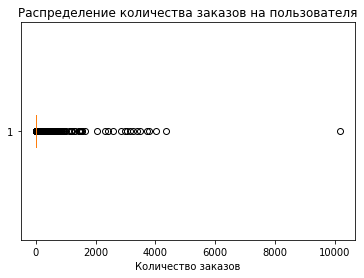

In [52]:
plt.figure(figsize=(6, 4))
plt.boxplot(user_profile['total_orders'], vert=False)
plt.xlabel('Количество заказов')
plt.title('Распределение количества заказов на пользователя')
plt.show()

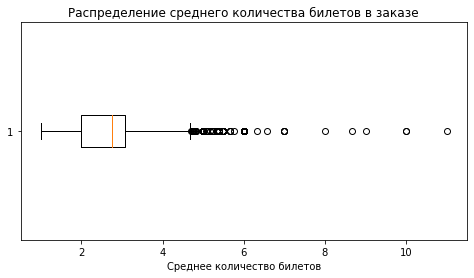

In [53]:
plt.figure(figsize=(8, 4))
plt.boxplot(user_profile['avg_tickets_count'], vert=False)
plt.xlabel('Среднее количество билетов')
plt.title('Распределение среднего количества билетов в заказе')
plt.show()

`total_orders` имеет очень сильный выброс:

- 95% пользователей сделали не больше 31 заказа;
- 99%  не больше 152 заказов;
- максимум - 10 181 заказов.

То есть между 99-м перцентилем и максимумом разница почти в 67 раз. Такие пользователи будут сильно искажать средние и графики. Здесь логичнее всего отфильтровать `total_orders` по 99% перцентилю.

In [54]:
orders_99 = user_profile['total_orders'].quantile(0.99)

In [55]:
users_before = len(user_profile)

In [56]:
user_profile_filtered = user_profile[user_profile['total_orders'] <= orders_99]

In [57]:
users_after = len(user_profile_filtered)

In [58]:
removed_users = users_before - users_after
removed_p = removed_users / users_before * 100

In [59]:
print(f'99% перцентиль total_orders: {orders_99:.0f}')
print(f'Пользователей до фильтрации: {users_before}')
print(f'Пользователей после фильтрации: {users_after}')
print(f'Удалено пользователей: {removed_users}')
print(f'Доля удалённых пользователей: {removed_p:.2f}%')

99% перцентиль total_orders: 152
Пользователей до фильтрации: 21854
Пользователей после фильтрации: 21638
Удалено пользователей: 216
Доля удалённых пользователей: 0.99%


In [60]:
user_profile_filtered[['total_orders', 'avg_tickets_count', 'avg_days_since_prev']].describe()

,total_orders,avg_tickets_count,avg_days_since_prev
count,21638.000000,21638.000000,13299.000000
mean,6.501294,2.743319,16.097245
std,14.324031,0.917486,22.391810
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.333333
50%,2.000000,2.750000,8.363636
75%,5.000000,3.095238,20.800000
max,152.000000,11.000000,148.000000


Анализ перцентилей подтвердил наличие выраженных аномалий в количестве заказов на пользователя.

Для `total_orders`:
- медиана составляет **2 заказа**;
- 75% пользователей совершили не более **5 заказов**;
- 95%  не более примерно **31 заказа**;
- 99%  не более **152 заказов**;
- максимальное значение  **10 181 заказа**.

Таким образом, между 99 перцентилем и максимальным значением наблюдается очень большой разрыв. Такие пользователи существенно отличаются от основной выборки и могут искажать средние показатели, распределения и результаты последующего анализа. Поэтому принято решение отфильтровать пользователей со значением `total_orders` выше 99 перцентиля, тк выше 99 перцентиля находится небольшая группа пользователей с экстремально высокой частотой заказов, которая существенно отличается от основной выборки.

После удаления верхнего 1% наблюдений среднее число заказов снизилось с **13.17** до **6.50**, при этом медиана осталась равной **2**, а 75 перцентиль - **5**. Это показывает, что фильтрация убрала преимущественно экстремальные значения и практически не изменила характеристики основной массы пользователей.

Поэтому порог 99 перцентиля позволяет уменьшить влияние аномалий на дальнейший анализ, сохранив при этом **99% пользовательских профилей**.

Для `avg_tickets_count` распределение выглядит значительно более устойчивым: 99% пользователей покупают в среднем не более **5 билетов** за заказ, а максимальное значение составляет **11**. Несмотря на наличие правого хвоста, разрыв не настолько велик, поэтому дополнительная фильтрация по этому признаку не проводится.

Средний интервал между покупками также не демонстрирует критических аномалий: у 99% пользователей он не превышает **112 дней**, максимальное значение составляет **148 дней**.

Таким образом, для дальнейшего анализа будет использоваться пользовательский профиль, очищенный от верхнего 1% аномальных значений по количеству заказов.

После удаления пользователей со значением `total_orders` выше 99 перцентиля в выборке осталось **21 638 пользователей**.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Сначала сделаем универсальную функцию, которая для любого столбца посчитает, чтобы потом ее применять к любому признаку:

- число пользователей в сегменте;
- долю пользователей (в %);
- отсортирует сегменты от самого крупного к самому маленькому.

In [61]:
def segmentation(data, column):
    result=data.groupby(column).agg(users_count=('user_id', 'count')).reset_index()    
    result['users_share'] = round(result['users_count']*100 / result['users_count'].sum(),1)
    return result.sort_values('users_count',ascending=False).reset_index(drop=True)

In [62]:
#посмотрим распределение по 4 признакам
event_segm = segmentation(user_profile_filtered,'first_event_type')
event_segm

,first_event_type,users_count,users_share
0,концерты,9560,44.2
1,другое,5426,25.1
2,театр,4239,19.6
3,стендап,1110,5.1
4,спорт,794,3.7
5,выставки,414,1.9
6,ёлки,95,0.4


In [63]:
device_segm = segmentation(user_profile_filtered,'first_device')
device_segm

,first_device,users_count,users_share
0,mobile,17924,82.8
1,desktop,3714,17.2


In [64]:
region_segm = segmentation(user_profile_filtered,'first_region')
region_segm.head(5)

,first_region,users_count,users_share
0,Каменевский регион,7085,32.7
1,Североярская область,3767,17.4
2,Широковская область,1224,5.7
3,Озернинский край,675,3.1
4,Малиновоярский округ,525,2.4


In [65]:
service_segm = segmentation(user_profile_filtered,'first_service')
service_segm.head(10)

,first_service,users_count,users_share
0,Билеты без проблем,5186,24.0
1,Мой билет,2969,13.7
2,Лови билет!,2809,13.0
3,Билеты в руки,2559,11.8
4,Облачко,2177,10.1
5,Весь в билетах,1285,5.9
6,Лучшие билеты,1184,5.5
7,Прачечная,583,2.7
8,Край билетов,454,2.1
9,Дом культуры,356,1.6



Распределение пользователей по признакам первого заказа неравномерно, и по нескольким характеристикам видны выраженные «точки входа».

По типу первого мероприятия крупнейшим сегментом являются **концерты** - с них начали взаимодействие с сервисом **44.18% пользователей**. Далее идут категория **«другое»** - **25.08%** и **театр** - **19.59%**. Остальные типы мероприятий заметно уступают по доле пользователей. Таким образом, концерты являются основной точкой входа по типу события.

По устройству распределение ещё более выраженное: **82.8% пользователей** совершили первую покупку с мобильного устройства и только **17.2%** - с компьютера. Мобильные устройства являются явной основной точкой входа в сервис.

По регионам также наблюдается концентрация пользователей. На **Каменевский регион** приходится **32.7%** пользователей, а на **Североярскую область** - ещё **17.4%**. Вместе эти два региона формируют около половины всех первых заказов, тогда как доли остальных регионов значительно ниже.

По билетным операторам распределение более ровно, но лидеры также заметны. Наибольшая доля первых заказов приходится на оператора **«Билеты без проблем»**  **24.0%**. Далее следуют **«Мой билет»**  **13.7%**, **«Лови билет!»**  **13.0%**, **«Билеты в руки»**  **11.8%** и **«Облачко»**  **10.1%**.

Таким образом, пользователи распределены по сегментам неравномерно. Наиболее выраженные точки входа: мобильные устройства, концерты, Каменевский регион и оператор «Билеты без проблем». Эти сегменты формируют заметную долю первых взаимодействий пользователей с сервисом и заслуживают отдельного внимания в дальнейшем анализе возврата пользователей.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [66]:
#средний возврат клиентов по всей выборке данных
overall_return_rate = user_profile_filtered['is_two'].mean() * 100
print(f'Средняя доля пользователей с повторным заказом: {overall_return_rate:.2f}%')

Средняя доля пользователей с повторным заказом: 61.33%


In [67]:
#функция, которая далее будет применяться ко всем сегментам
def segment_return(data, column):
    result = data.groupby(column).agg(users_count=('user_id', 'count'), return_rate=('is_two', 'mean')).reset_index()
    result['return_rate'] = round(result['return_rate'] * 100,2)
    return result.sort_values('users_count',ascending=False).reset_index(drop=True)

In [68]:
event_return = segment_return(user_profile_filtered,'first_event_type')
event_return

,first_event_type,users_count,return_rate
0,концерты,9560,61.83
1,другое,5426,59.62
2,театр,4239,63.39
3,стендап,1110,60.90
4,спорт,794,55.79
5,выставки,414,64.01
6,ёлки,95,55.79


In [69]:
device_return = segment_return(user_profile_filtered,'first_device')
device_return

,first_device,users_count,return_rate
0,mobile,17924,60.81
1,desktop,3714,63.81


In [70]:
region_return = segment_return(user_profile_filtered,'first_region')
region_return.head(20)

,first_region,users_count,return_rate
0,Каменевский регион,7085,62.40
1,Североярская область,3767,63.82
2,Широковская область,1224,64.54
3,Озернинский край,675,55.26
4,Малиновоярский округ,525,56.00
5,Шанырский регион,500,67.20
6,Травяная область,488,61.48
7,Светополянский округ,457,65.65
8,Речиновская область,440,63.41
9,Яблоневская область,411,59.37


In [71]:
service_return = segment_return(user_profile_filtered,'first_service')
service_return.head(20)

,first_service,users_count,return_rate
0,Билеты без проблем,5186,60.41
1,Мой билет,2969,60.86
2,Лови билет!,2809,60.91
3,Билеты в руки,2559,62.72
4,Облачко,2177,61.28
5,Весь в билетах,1285,62.88
6,Лучшие билеты,1184,61.23
7,Прачечная,583,62.61
8,Край билетов,454,65.20
9,Дом культуры,356,64.61


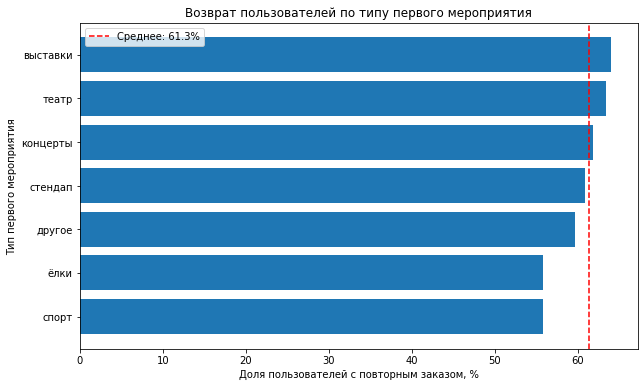

In [72]:
plot_data = event_return.sort_values('return_rate')
plt.figure(figsize=(10, 6))
plt.barh(plot_data['first_event_type'], plot_data['return_rate'])
plt.axvline(
    overall_return_rate,
    color='red',
    linestyle='--',
    label=f'Среднее: {overall_return_rate:.1f}%')

plt.xlabel('Доля пользователей с повторным заказом, %')
plt.ylabel('Тип первого мероприятия')
plt.title('Возврат пользователей по типу первого мероприятия')
plt.legend()
plt.show()

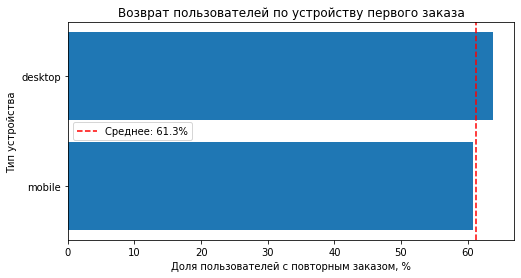

In [73]:
plot_data = device_return.sort_values('return_rate')
plt.figure(figsize=(8, 4))
plt.barh(plot_data['first_device'], plot_data['return_rate'])
plt.axvline(
    overall_return_rate,
    color='red',
    linestyle='--',
    label=f'Среднее: {overall_return_rate:.1f}%')

plt.xlabel('Доля пользователей с повторным заказом, %')
plt.ylabel('Тип устройства')
plt.title('Возврат пользователей по устройству первого заказа')
plt.legend()
plt.show()

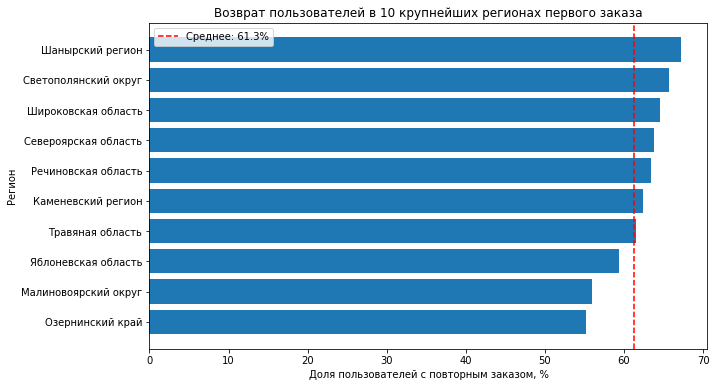

In [74]:
plot_data = region_return.head(10).sort_values('return_rate')
plt.figure(figsize=(10, 6))
plt.barh(plot_data['first_region'], plot_data['return_rate'])

plt.axvline(
    overall_return_rate,
    color='red',
    linestyle='--',
    label=f'Среднее: {overall_return_rate:.1f}%')

plt.xlabel('Доля пользователей с повторным заказом, %')
plt.ylabel('Регион')
plt.title('Возврат пользователей в 10 крупнейших регионах первого заказа')
plt.legend()
plt.show()

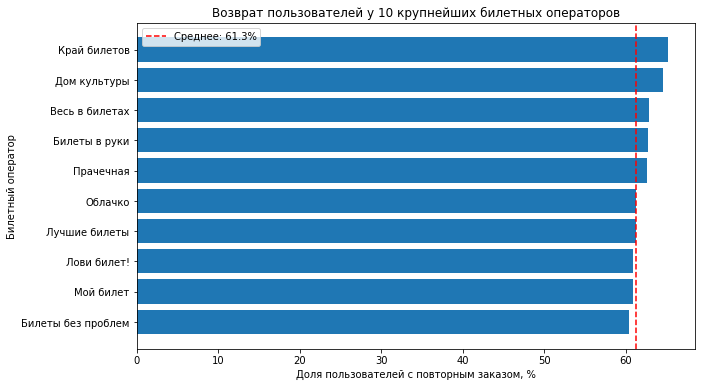

In [75]:
plot_data = service_return.head(10).sort_values('return_rate')
plt.figure(figsize=(10, 6))
plt.barh(plot_data['first_service'], plot_data['return_rate'])
plt.axvline(
    overall_return_rate,
    color='red',
    linestyle='--',
    label=f'Среднее: {overall_return_rate:.1f}%')

plt.xlabel('Доля пользователей с повторным заказом, %')
plt.ylabel('Билетный оператор')
plt.title('Возврат пользователей у 10 крупнейших билетных операторов')
plt.legend()
plt.show()

***Вывод***

Средняя доля пользователей, совершивших два и более заказа, по отфильтрованной выборке составляет около **61.3%**. Это значение можно использовать как ориентир для поиска успешных «точек входа».

По типу первого мероприятия наиболее высокая доля возврата наблюдается у пользователей, впервые купивших билеты на **выставки - 64.01%**, и в **театр - 63.39%**. Оба сегмента находятся выше среднего уровня по выборке. Концерты, несмотря на то что являются крупнейшей точкой входа по числу пользователей, имеют долю возврата **61.83%**, то есть лишь немного выше среднего. Самая низкая доля возврата среди крупных категорий наблюдается у пользователей, впервые пришедших на **спорт - 55.79%**. Категория «ёлки» показывает такой же уровень, но содержит всего 95 пользователей, поэтому её результат менее достоверен.

По типу устройства пользователи, совершившие первый заказ с **desktop**, возвращаются чаще - **63.81%** против **60.81%** у пользователей mobile. При этом mobile остаётся значительно более крупным сегментом, поэтому даже небольшое улучшение возврата мобильных пользователей может иметь бОльший эффект.

По регионам среди крупнейших сегментов наиболее высокий возврат наблюдается в **Шанырском регионе - 67.20%**, **Светополянском округе- 65.65%**, **Широковской области- 64.54%** и **Североярской области - 63.82%**. Каменевский регион, который является крупнейшей точкой входа, также показывает возврат выше среднего - **62.40%**. Это делает его особенно важным сегментом: он одновременно крупный и демонстрирует хорошую долю повторных заказов. Самые интересные регионы все еще остаются те, которые одновременно имеют достаточно большую аудиторию и долю повторных заказов на уровне или выше среднего. К таким сегментам относятся **Каменевский регион**, **Североярская область** и **Широковская область**.

Среди билетных операторов наиболее успешными среди достаточно крупных сегментов можно назвать **«Край билетов» - 65.20%**, **«Дом культуры»- 64.61%**, **«Весь в билетах» - 62.88%** и **«Билеты в руки» - 62.72%**. Крупнейший оператор **«Билеты без проблем»** имеет возврат клиентов **60.41%**, что немного ниже среднего уровня выборки, однако количество клиентов у него выше.

Некоторые небольшие сегменты показывают очень высокий возврат, например **«Быстрый кассир» - 85.25%** и **«Восьмёрка» - 68.24%**, однако в них всего 61 и 85 пользователей. Такие значения могут быть менее репрезентативны с точки зрения выборки.

В целом успешными «точками входа» можно считать сегменты, которые одновременно достаточно велики и имеют долю повторных заказов выше среднего. К таким сегментам относятся: театр, выставки, desktop, Каменевский регион, Североярская и Широковская области, а также несколько крупных билетных операторов («Край билетов», Билеты без проблем, Мой билет, Лови билет!, Билеты в руки, Облачко, Весь в билетах, Лучшие билеты все еще в топе по возврату клиентов, т.к. имеют большее количетво пользователей при чуть сниженном от среднего процента возврата клиентов). 

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [76]:
event_return[(event_return['first_event_type'] == 'спорт') |
    (event_return['first_event_type'] == 'концерты')]

,first_event_type,users_count,return_rate
0,концерты,9560,61.83
4,спорт,794,55.79


 *Вывод по гипотезе 1:*

**Гипотеза:** пользователи, которые совершили первый заказ на спортивное мероприятие, совершают повторный заказ чаще, чем пользователи, впервые купившие билеты на концерт.

Доля пользователей с повторными заказами составляет:

- спорт  **55.79%**;
- концерты  **61.83%**.

Таким образом, пользователи, впервые купившие билеты на концерты, возвращаются чаще, чем пользователи, чей первый заказ был связан со спортивным мероприятием. 

**Гипотеза не подтверждается.**

In [77]:
#для гипотезы 2 посмотрим на корелляцию количества пользователей и из возврат от размера региона
region_corr = region_return[['users_count', 'return_rate']].corr(method='spearman')
region_corr

,users_count,return_rate
users_count,1.000000,0.311099
return_rate,0.311099,1.000000


Корелляция не выглядит как явная зависимость. Более крупные регионы действительно в среднем склонны иметь чуть более высокий процент возврата клиентов, но связь не сильная.

In [78]:
#посмотрим на уже полученную таблицу
region_return = segment_return(user_profile_filtered,'first_region')
region_return.head(15)

,first_region,users_count,return_rate
0,Каменевский регион,7085,62.40
1,Североярская область,3767,63.82
2,Широковская область,1224,64.54
3,Озернинский край,675,55.26
4,Малиновоярский округ,525,56.00
5,Шанырский регион,500,67.20
6,Травяная область,488,61.48
7,Светополянский округ,457,65.65
8,Речиновская область,440,63.41
9,Яблоневская область,411,59.37


In [79]:
round(region_return['return_rate'].head(9).mean(),2)

62.2

In [80]:
round(region_return['return_rate'].iloc[10:21].mean(),2)

59.11

*Вывод по гипотезе 2*:

**Гипотеза:** в регионах с наибольшим количеством пользователей доля повторных заказов выше, чем в менее активных регионах.

Для оценки связи между размером регионального сегмента и долей повторных заказов была рассчитана корреляция Спирмена между `users_count` и `return_rate`.

Коэффициент корреляции составил **0.31**, что указывает на слабую положительную связь: с ростом количества пользователей в регионе доля повторных заказов в среднем имеет тенденцию увеличиваться.

При этом связь не является сильной. Среди крупных регионов встречаются как сегменты с возвратом выше среднего, например Каменевский регион, Североярская и Широковская области, так и крупные регионы с относительно низкой долей повторных покупок (Озерниский край). Аналогично, некоторые менее крупные регионы показывают высокий `return_rate`. При этом, необходимо определиться что можно считать за "крупный" регион, если регион с количеством пользователей больше 1000, то это топ-3 региона и средний процент возврата пользователей составляет 63.59% против ~60% (если мы будем смотреть топ-20 регионов). Если за Крупные регионы считать первые 10, то средний процент возврата пользователей снижается до 62%, однако процент возврата в регионах с еще более низким количеством пользователей снизится до 59%.

Таким образом, **гипотеза подтверждается**: более активные регионы в среднем демонстрируют несколько более высокий уровень возврата. 

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [81]:
#пользователи с 1 заказом
one_order = user_profile_filtered[user_profile_filtered['total_orders'] == 1]

In [82]:
repeat_users = user_profile_filtered[user_profile_filtered['total_orders'] >= 2]

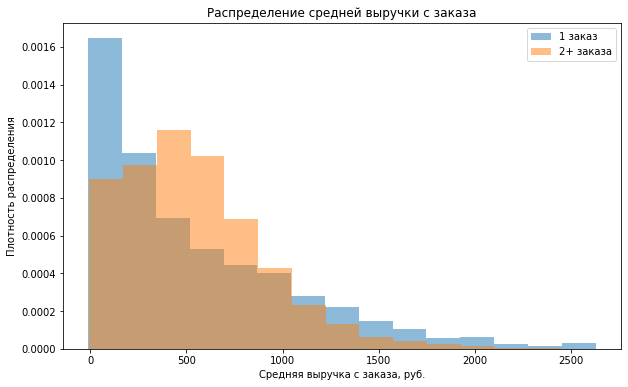

In [83]:
import numpy as np

plt.figure(figsize=(10, 6))

plt.hist(
    one_order['avg_revenue_rub'],
    bins=15,
    alpha=0.5,
    density=True,
    label='1 заказ')

plt.hist(
    repeat_users['avg_revenue_rub'],
    bins=15,
    alpha=0.5,
    density=True,
    label='2+ заказа')

plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения')
plt.title('Распределение средней выручки с заказа')
plt.legend()
plt.show()

In [84]:
print('Пользователи с одним заказом:')
print(one_order['avg_revenue_rub'].describe())

print('\nПользователи с 2+ заказами:')
print(repeat_users['avg_revenue_rub'].describe())

Пользователи с одним заказом:
count    8368.000000
mean      545.295642
std       519.514097
min       -10.770000
25%       132.070000
50%       378.030000
75%       830.317500
max      2628.421739
Name: avg_revenue_rub, dtype: float64

Пользователи с 2+ заказами:
count    13270.000000
mean       544.337170
std        369.354468
min         -5.385000
25%        270.814375
50%        495.772429
75%        745.165500
max       2628.421739
Name: avg_revenue_rub, dtype: float64


**Вывод:**

Распределения средней выручки у двух групп заметно отличаются по форме, хотя средние значения практически совпадают:

- пользователи с одним заказом среднее около **545 руб.**
- пользователи с 2 и более заказами среднее около **544 руб.**

При этом медианы различаются сильнее:
- для пользователей с одним заказом медиана составляет около **378 руб.**
- для вернувшихся пользователей  около **496 руб.**

У пользователей с одним заказом распределение сильнее смещено вправо: заметная часть значений сосредоточена в диапазоне примерно 
до **300-400 руб.**, но при этом присутствует длинный хвост в сторону высокой выручки. Это подтверждается и более высоким стандартным отклонением  около **520 руб.**

У пользователей с 2 и более заказами распределение более компактное и сосредоточено преимущественно в диапазоне примерно 
**300-800 руб.** Стандартное отклонение у этой группы ниже около **369 руб.**, то есть средняя выручка по пользователям распределена более равномерно.

Таким образом, средняя выручка с заказа сама по себе почти не различается между группами, однако характер распределения отличается: пользователи с повторными заказами чаще имеют значения средней выручки в среднем диапазоне, тогда как среди пользователей с одним заказом больше как низких, так и очень высоких значений.

У вернувшихся пользователей распределение средней выручки более близко к нормальному и имеет более высокую медиану.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [85]:
#выделим 2 группы
group_2_4 = user_profile_filtered[(user_profile_filtered['total_orders'] >= 2) & (user_profile_filtered['total_orders'] <= 4)]
group_5_plus = user_profile_filtered[user_profile_filtered['total_orders'] >= 5]

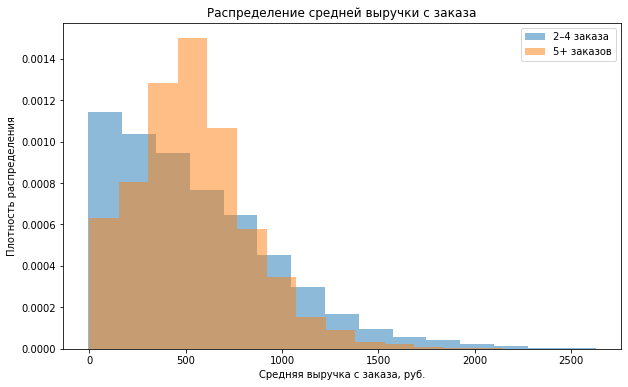

In [86]:
plt.figure(figsize=(10, 6))

plt.hist(
    group_2_4['avg_revenue_rub'],
    bins=15,
    alpha=0.5,
    density=True,
    label='2–4 заказа')

plt.hist(
    group_5_plus['avg_revenue_rub'],
    bins=15,
    alpha=0.5,
    density=True,
    label='5+ заказов')

plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения')
plt.title('Распределение средней выручки с заказа')
plt.legend()
plt.show()

In [87]:
print('Пользователи с 2–4 заказами:')
print(group_2_4['avg_revenue_rub'].describe())

print('\nПользователи с 5+ заказами:')
print(group_5_plus['avg_revenue_rub'].describe())

Пользователи с 2–4 заказами:
count    7147.000000
mean      551.572386
std       420.197691
min        -5.385000
25%       218.428750
50%       471.266667
75%       798.550000
max      2628.421739
Name: avg_revenue_rub, dtype: float64

Пользователи с 5+ заказами:
count    6123.000000
mean      535.891950
std       299.089582
min         0.000000
25%       330.456122
50%       512.650613
75%       700.809038
max      2299.869022
Name: avg_revenue_rub, dtype: float64


Тут наблюдается аналогичная ситуация как при сравнении групп "1заказ, 2+ заказа".

Распределения средней выручки с заказа в двух группах заметно отличаются по форме, хотя средние значения остаются близкими:

- пользователи с 2-4 заказами  средняя выручка около **552 руб.**;
- пользователи с 5 и более заказами  около **536 руб.**.

Медиана, наоборот, выше у более активных пользователей:
- **471 руб.** для группы с 2-4 заказами;
- **513 руб.** для группы с 5 и более заказами.

У пользователей с 2-4 заказами распределение более растянуто: стандартное отклонение составляет около **420 руб.**, а у пользователей с 5+ заказами около **299 руб.** Это означает, что значения средней выручки у более активных пользователей сосредоточены плотнее.

По графику видно, что пользователи с 5 и более заказами чаще концентрируются примерно в диапазоне **400-700 руб.**, тогда как у пользователей с 2-4 заказами больше как низких, так и высоких значений средней выручки.

Таким образом, выраженного различия по среднему уровню выручки между группами нет. Однако у пользователей с 5+ заказами распределение более компактное и медианная выручка немного выше. Это говорит скорее о более стабильном уровне расходов у часто возвращающихся пользователей, чем о заметно большей средней выручке с заказа.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе (***включительно???!?!***):
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [88]:
#распределение пользователей по среднему кол-ву билетов в заказе
user_profile_filtered['avg_tickets_count'].describe()

count    21638.000000
mean         2.743319
std          0.917486
min          1.000000
25%          2.000000
50%          2.750000
75%          3.095238
max         11.000000
Name: avg_tickets_count, dtype: float64

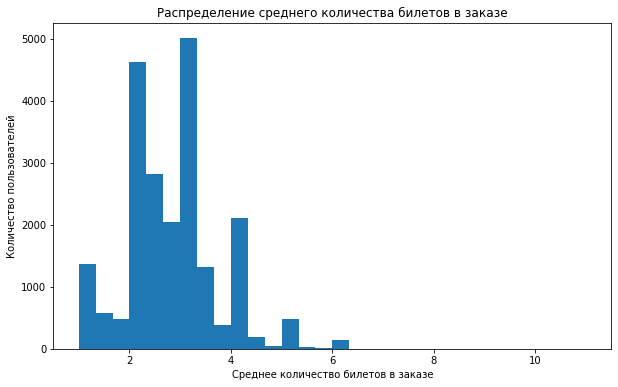

In [89]:
plt.figure(figsize=(10, 6))

plt.hist(user_profile_filtered['avg_tickets_count'],bins=30)

plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего количества билетов в заказе')
plt.show()

Основное количество пользователей приобретает около 2-3 билетов: среднее 2.74, медиана 2.75, а 75% пользователей имеют среднее количество билетов не выше 3 билетов. Максимум 11, но таких пользователей, вероятно, совсем немного.

In [92]:
user_profile_filtered = user_profile[user_profile['total_orders'] <= orders_99].copy()

In [159]:
#делаем срез сегментов по количеству билетов
user_profile_filtered['tickets_segment'] = pd.cut(user_profile_filtered['avg_tickets_count'],bins=[0, 2, 3, 5, 12],
    labels=[
        '1-2 билета',
        '2-3 билета',
        '3-5 билетов',
        '5+ билетов'], right=True)

In [160]:
#это распределение, если правую границу мы включаем, то есть челвоек прииобрел 1\2 билета или 2\3 билета 
#может попадать в первую категорию
user_profile_filtered['tickets_segment'].value_counts(sort=False)

1-2 билета     6160
2-3 билета     9935
3-5 билетов    5349
5+ билетов      194
Name: tickets_segment, dtype: int64

In [161]:
#считаем для каждого сегмента количество и долю пользователей с возвратом
tickets_segments = (user_profile_filtered.groupby('tickets_segment').agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')).reset_index())

In [162]:
tickets_segments['users_share'] = (tickets_segments['users_count']/tickets_segments['users_count'].sum()* 100).round(2)

In [163]:
tickets_segments['return_rate'] = (tickets_segments['return_rate']*100).round(2)
tickets_segments

,tickets_segment,users_count,return_rate,users_share
0,1-2 билета,6160,40.15,28.47
1,2-3 билета,9935,74.28,45.91
2,3-5 билетов,5349,62.70,24.72
3,5+ билетов,194,32.47,0.90


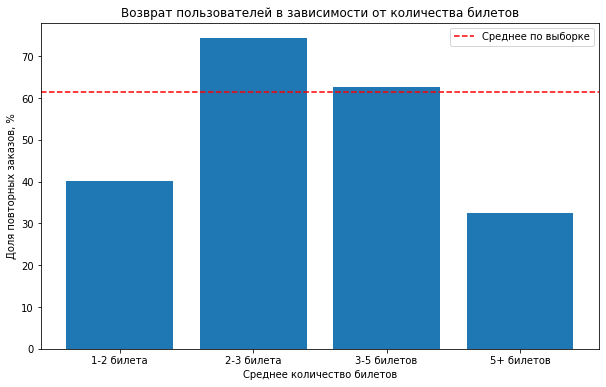

In [167]:
plt.figure(figsize=(10, 6))

plt.bar(tickets_segments['tickets_segment'],tickets_segments['return_rate'])

plt.axhline(user_profile_filtered['is_two'].mean() * 100,
    linestyle='--',
    label='Среднее по выборке',
    color='red')

plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля повторных заказов, %')
plt.title('Возврат пользователей в зависимости от количества билетов')
plt.legend()
plt.show()

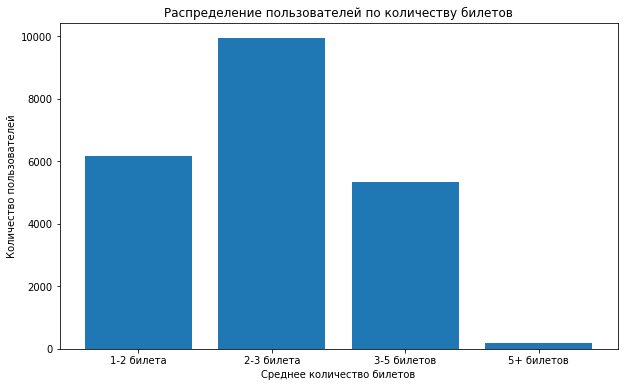

In [168]:
plt.figure(figsize=(10, 6))

plt.bar(tickets_segments['tickets_segment'],tickets_segments['users_count'])

plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по количеству билетов')
plt.show()

***Вывод по влиянию количества билетов на повторные покупки***

Пользователи распределены по сегментам неравномерно.

Наибольшая часть пользователей находится в сегменте со средним количеством **2-3 билета на заказ** это **45.91%** выборки. На втором месте пользователи со средним количеством **1-2 билета** это **28.47%**, затем сегмент **3-5 билетов** это **24.72%**. Пользователи со средним количеством **5 и более билетов** встречаются крайне редко всего **0.90%** от выборки.

Доля повторных покупок заметно различается между сегментами:
- **1-2 билета**  **40.15%**;
- **2-3 билета**  **74.28%**;
- **3-5 билетов**  **62.70%**;
- **5+ билетов**  **32.47%**.

Самая высокая доля возврата наблюдается у пользователей, которые в среднем покупают **2–3 билета** за заказ. Этот сегмент одновременно является самым крупным, поэтому его можно считать особенно важным с точки зрения удержания пользователей.

Сегмент **3-5 билетов** также показывает высокий уровень повторных покупок **62.70%**, близкий к среднему уровню по выборке.

Заметно ниже вероятность возврата у пользователей со средним количеством **1-2 билета** около **40%**.

Самый низкий `return_rate` наблюдается в сегменте **5+ билетов** **32.47%**, однако этот сегмент очень мал и включает только **194 пользователя**, или менее 1% выборки.

Таким образом, наиболее высокая вероятность повторной покупки наблюдается при среднем размере заказа **2-3 билета**, тогда как как меньшие, так и особенно крупные заказы связаны с более низкой долей возврата.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [169]:
#выделим день недели
user_profile_filtered['first_weekday_num'] = (user_profile_filtered['first_order_dt'].dt.dayofweek)

In [171]:
#заменим, чтобы не путаться в цифрах-днях неделях
weekdays = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'}

user_profile_filtered['first_weekday'] = (user_profile_filtered['first_weekday_num'].map(weekdays))

In [175]:
weekday_return = (user_profile_filtered.groupby(['first_weekday_num', 'first_weekday']).agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')).reset_index().sort_values('first_weekday_num'))

weekday_return['return_rate'] = round(weekday_return['return_rate'] *100,2)
weekday_return

,first_weekday_num,first_weekday,users_count,return_rate
0,0,Понедельник,2930,63.04
1,1,Вторник,3176,61.90
2,2,Среда,3057,62.19
3,3,Четверг,3113,59.43
4,4,Пятница,3259,59.83
5,5,Суббота,3326,62.81
6,6,Воскресенье,2777,60.03


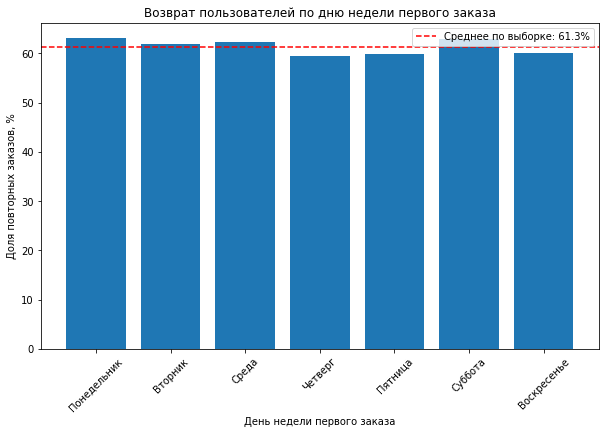

In [178]:
plt.figure(figsize=(10, 6))

plt.bar(weekday_return['first_weekday'],weekday_return['return_rate'])

plt.axhline(
    overall_return_rate,
    linestyle='--',
    color='red',
    label=f'Среднее по выборке: {overall_return_rate:.1f}%')

plt.xlabel('День недели первого заказа')
plt.ylabel('Доля повторных заказов, %')
plt.title('Возврат пользователей по дню недели первого заказа')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Количество пользователей по дням недели распределено достаточно равномерно: в каждый день первую покупку совершили примерно от **2.8 до 3.3 тыс. пользователей**. Поэтому размер групп не будет оказывать сильного влияния.

Доля пользователей, совершивших повторные покупки, находится в диапазоне от **59.43% до 63.04%**:

- максимальная доля возврата наблюдается у пользователей, впервые совершивших покупку в **понедельник 63.04%**;
- также относительно высокий возврат наблюдается в **субботу  62.81%**, среду  **62.19%** и вторник  **61.90%**;
- минимальная доля возврата наблюдается для первой покупки в **четверг  59.43%** и пятницу  **59.83%**.

Различия между днями недели относительно небольшие.

Таким образом, **явного сильного влияния дня недели первой покупки на вероятность возврата не наблюдается**. Можно отметить немного более высокий возврат для пользователей, впервые купивших билеты в понедельник и субботу, и более низкий в четверг и пятницу, однако в целом показатели достаточно близки друг к другу.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [179]:
#разбиваем на сегменты
group_2_4 = user_profile_filtered[(user_profile_filtered['total_orders'] >= 2) & (user_profile_filtered['total_orders'] <= 4)]

group_5_plus = user_profile_filtered[user_profile_filtered['total_orders'] >= 5]

In [183]:
print('Средний интервал, 2-4 заказа:',round(group_2_4['avg_days_since_prev'].mean(),1))

print('Средний интервал, 5+ заказов:', round(group_5_plus['avg_days_since_prev'].mean(),1))

Средний интервал, 2-4 заказа: 21.3
Средний интервал, 5+ заказов: 9.9


In [186]:
group_2_4['avg_days_since_prev'].describe()

count    7147.000000
mean       21.320787
std        28.476836
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
max       148.000000
Name: avg_days_since_prev, dtype: float64

In [187]:
group_5_plus['avg_days_since_prev'].describe()

count    6123.000000
mean        9.907170
std         7.808205
min         0.000000
25%         3.884034
50%         8.125000
75%        14.125000
max        37.500000
Name: avg_days_since_prev, dtype: float64

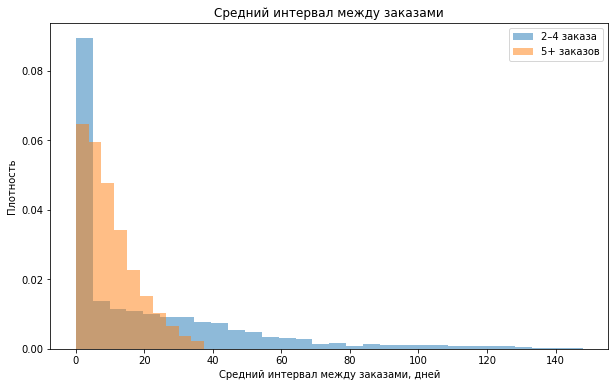

In [194]:
plt.figure(figsize=(10, 6))

plt.hist(
    group_2_4['avg_days_since_prev'],
    bins=30,
    alpha=0.5,
    density=True,
    label='2–4 заказа')

plt.hist(
    group_5_plus['avg_days_since_prev'],
    bins=10,
    alpha=0.5,
    density=True,
    label='5+ заказов')

plt.xlabel('Средний интервал между заказами, дней')
plt.ylabel('Плотность')
plt.title('Средний интервал между заказами')
plt.legend()
plt.show()

Средний интервал между заказами заметно отличается в зависимости от количества совершённых покупок.

Для пользователей с **2-4 заказами** средний интервал составляет **21.3 дня**, тогда как для пользователей с **5 и более заказами**  почти **10 дней**.

При этом медианные значения различаются слабее:
- **2- 4 заказа**  **9 дней**;
- **5+ заказов**  **8.1 дня**.

Такое различие между средним и медианой особенно заметно в группе пользователей с 2-4 заказами. Среднее значение сильно увеличивается за счёт пользователей с очень большими интервалами между покупками: максимальный интервал в этой группе достигает **148 дней**, а стандартное отклонение составляет **28.5 дня**.

У пользователей с 5 и более заказами распределение значительно более компактное: 75% пользователей совершают следующий заказ в среднем не позднее чем через **14.1 дня**, а максимальный средний интервал составляет **37.5 дня**.

Таким образом, пользователи с более высокой частотой покупок в среднем возвращаются заметно быстрее. Это указывает на связь между коротким интервалом между заказами и более высоким удержанием: чем регулярнее пользователь совершает покупки, тем меньше среднее время между ними.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [197]:
corr_columns = [
    'total_orders',
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'first_weekday',
    'avg_revenue_rub',
    'avg_tickets_count']

profile_corr = user_profile_filtered[corr_columns]

In [202]:
#явно укажем, что это точно интервал, чтобы метод не гадал
#interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets_count']
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count']

In [203]:
phik_matrix = profile_corr.phik_matrix(
    interval_cols=interval_cols)

phik_matrix

,total_orders,first_device,first_region,first_service,first_event_type,first_weekday,avg_revenue_rub,avg_tickets_count
total_orders,1.000000,0.025945,0.113663,0.027483,0.027745,0.060831,0.219482,0.225904
first_device,0.025945,1.000000,0.116370,0.083156,0.061771,0.073356,0.076388,0.055562
first_region,0.113663,0.116370,1.000000,0.696538,0.509207,0.152721,0.363157,0.163874
first_service,0.027483,0.083156,0.696538,1.000000,0.587561,0.062494,0.378845,0.065908
first_event_type,0.027745,0.061771,0.509207,0.587561,1.000000,0.083437,0.329006,0.095617
first_weekday,0.060831,0.073356,0.152721,0.062494,0.083437,1.000000,0.016283,0.003671
avg_revenue_rub,0.219482,0.076388,0.363157,0.378845,0.329006,0.016283,1.000000,0.458801
avg_tickets_count,0.225904,0.055562,0.163874,0.065908,0.095617,0.003671,0.458801,1.000000


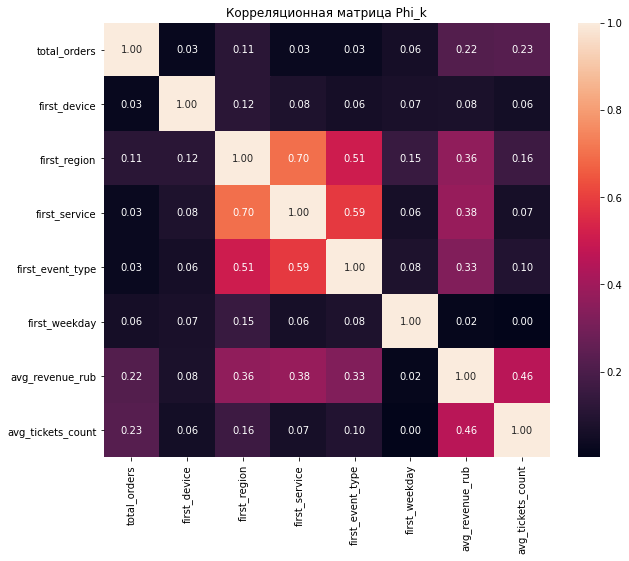

In [205]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.2f')

plt.title('Корреляционная матрица Phi_k')
plt.show()

По результатам расчёта коэффициента `phi_k` наиболее заметная связь с количеством заказов наблюдается у:

- среднего количества билетов в заказе  `phi_k ≈ 0.23`;
- средней выручки с заказа  `phi_k ≈ 0.22`;
- региона первого заказа  `phi_k ≈ 0.11`.

Остальные признаки имеют очень слабую связь с количеством заказов: значения коэффициента находятся вблизи нуля.

Таким образом, ни один из рассматриваемых признаков не показывает сильной связи с числом покупок. Наиболее заметными факторами являются среднее количество билетов и средняя стоимость заказа, однако и для них связь остаётся слабой.

Такой результат может быть связан с неравномерным распределением `total_orders`, поэтому далее пользователи будут разделены на группы по количеству заказов: 1 заказ, 2-4 заказа и 5+, после чего корреляционный анализ будет повторён.

In [211]:
user_profile_filtered['orders_segment'] = '1 заказ'

user_profile_filtered.loc[(user_profile_filtered['total_orders'] >= 2) & (user_profile_filtered['total_orders'] <= 4),
    'orders_segment'] = '2-4 заказа'

user_profile_filtered.loc[user_profile_filtered['total_orders'] >= 5,'orders_segment'] = '5+ заказов'

In [212]:
user_profile_filtered['orders_segment'].value_counts()

1 заказ       8368
2-4 заказа    7147
5+ заказов    6123
Name: orders_segment, dtype: int64

In [213]:
segment_corr_columns = [
    'orders_segment',
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'first_weekday',
    'avg_revenue_rub',
    'avg_tickets_count']

segment_corr = user_profile_filtered[segment_corr_columns]

In [214]:
interval_cols = ['avg_revenue_rub','avg_tickets_count']

In [216]:
phik_segment_matrix = segment_corr.phik_matrix(interval_cols=interval_cols)
phik_segment_matrix

,orders_segment,first_device,first_region,first_service,first_event_type,first_weekday,avg_revenue_rub,avg_tickets_count
orders_segment,1.000000,0.017110,0.123473,0.081308,0.040322,0.034267,0.326091,0.383366
first_device,0.017110,1.000000,0.116370,0.083156,0.061771,0.073356,0.076388,0.055562
first_region,0.123473,0.116370,1.000000,0.696538,0.509207,0.152721,0.363157,0.163874
first_service,0.081308,0.083156,0.696538,1.000000,0.587561,0.062494,0.378845,0.065908
first_event_type,0.040322,0.061771,0.509207,0.587561,1.000000,0.083437,0.329006,0.095617
first_weekday,0.034267,0.073356,0.152721,0.062494,0.083437,1.000000,0.016283,0.003671
avg_revenue_rub,0.326091,0.076388,0.363157,0.378845,0.329006,0.016283,1.000000,0.458801
avg_tickets_count,0.383366,0.055562,0.163874,0.065908,0.095617,0.003671,0.458801,1.000000


In [217]:
phik_segment_matrix['orders_segment'].sort_values(ascending=False)

orders_segment       1.000000
avg_tickets_count    0.383366
avg_revenue_rub      0.326091
first_region         0.123473
first_service        0.081308
first_event_type     0.040322
first_weekday        0.034267
first_device         0.017110
Name: orders_segment, dtype: float64

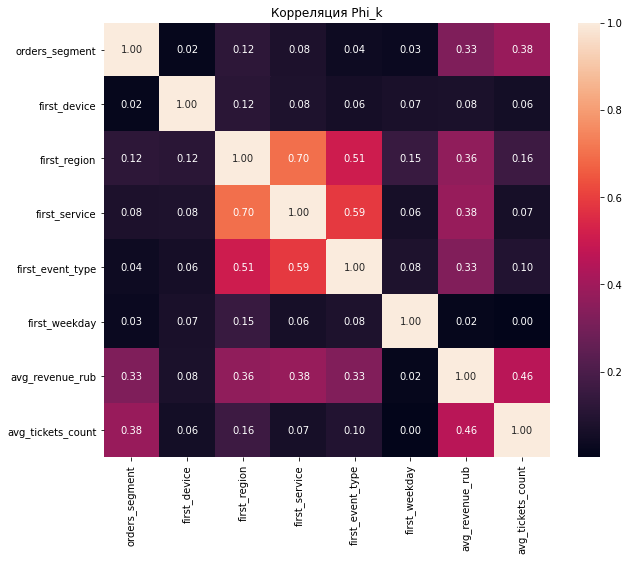

In [222]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    phik_segment_matrix,
    annot=True,
    fmt='.2f')

plt.title('Корреляция Phi_k')
plt.show()

***Вывод:***

После разделения пользователей на сегменты по количеству заказов связь с некоторыми характеристиками стала более выраженной.

Наиболее сильная связь с сегментом количества заказов наблюдается у:

- **среднего количества билетов в заказе**  `phi_k 0.38`;
- **средней выручки с заказа** `phi_k 0.33`.

Эти значения  заметно выше, чем при анализе исходного числового признака `total_orders`.

Значительно слабее связь с:
- регионом первого заказа  `phi_k 0.12`;
- сервисом первой покупки `phi_k  0.08`.

Тип первого мероприятия, день недели первой покупки и устройство практически не связаны с количеством совершённых заказов: для них `phi_k` близок к нулю.

Таким образом, среди рассмотренных характеристик наиболее тесно с количеством покупок связаны **среднее количество билетов в заказе** и **средняя выручка с заказа**. Сегментация пользователей позволила лучше выявить эти зависимости, которые были слабее заметны при использовании исходного `total_orders`.

Однако, коэффициент корреляции показывает наличие связи, но не позволяет сделать вывод о причинно-следственной зависимости.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

***Выводы и рекомендации:***

В рамках проекта были проанализированы данные о заказах пользователей билетного сервиса Яндекс.Афиша. Исходная выборка содержала около **291 тысяч заказов**. Перед анализом данные были подготовлены: даты приведены к нужному формату, стоимость заказов в тенге пересчитана в рубли по курсу на дату покупки блетов, проверены пропуски и категориальные значения. Для снижения влияния выбросов были исключены заказы выше 99% перцентиля по выручке, что составило около **1%** данных. Небольшие отрицательные значения выручки были сохранены, так как они могут отражать возвраты или корректировки. На уровне профилей пользователей также был исключён верхний 1% аномально активных пользователей по количеству заказов.

После фильтрации в анализе осталось **21 638 пользователей**. Большинство пользователей совершают небольшое число заказов: медиана составляет **2 заказа**, 75% пользователей сделали не более **5 заказов**. Один заказ совершили **8368 пользователей (38.7%)**, 2-4 заказа **7147 (33.0%)**, 5 и более **6123 (28.3%)**. Таким образом, около **61% пользователей возвращались хотя бы за раз за повторной покупкой**.

**Основные результаты**

Характеристики первого заказа связаны с возвратом неоднозначно. По типу мероприятия наиболее высокий возврат наблюдался у пользователей, впервые купивших билеты на выставки и в театр, однако сегмент выставок сравнительно небольшой. Среди крупных сегментов хорошие показатели показывает театр (**63.4%**) и концерты (**61.8%**), тогда как для спорта возврат ниже, около **55.8%**. Следовательно, гипотеза о том, что пользователи, впервые купившие билеты на спортивные события, возвращаются чаще посетителей концертов, не подтвердилась.

По регионам и сервисам также существуют различия, однако их необходимо оценивать вместе с размером сегмента. Например, Каменевский регион, Североярская и Широковская области одновременно имеют достаточно большую аудиторию и возврат около или выше среднего. У небольших регионов и сервисов высокий процент возврата однако крайне малое число пользователей.

Устройство первого заказа практически не определяет дальнейшее поведение. Большинство пользователей впервые совершали покупку с мобильного устройства (**около 83%**), при этом возврат пользователей desktop немного выше (но не существенно).

Средняя выручка с заказа сама по себе слабо разделяет пользователей по возврату. Средняя выручка от пользователей с одним заказом и у вернувшихся практически одинакова около **545 и 544 руб.** соответственно. Однако медиана у повторных пользователей выше (**около 496 руб. против 378 руб.**), а распределение выручки более собранное и компактное. Среди пользователей с 5+ заказами средняя стоимость заказа не выше, чем у группы с 2-4 заказами, но покупки более однородны. Поэтому высокая стоимость отдельной покупки не означает более высокую вероятность возврата.

Наиболее заметная связь обнаружена со **средним количеством билетов в заказе**. Самый крупный сегмент, а это пользователи со средним количеством **2-3 билета** (**45.9% пользователей**), имеет одновременно и самый высокий возврат: **74.3%**. Для 3-5 билетов возврат составляет **62.7%**, а для 1-2 билетов только **40.2%**. В группе 5+ билетов возврат ещё ниже **32.5%**, однако эта группа составляет всего **0.9% выборки**. Зависимость не является линейной: наиболее устойчивое поведение характерно именно для покупателей 2-3 билетов.

День недели первой покупки практически не влияет на дальнейшее удержание. Доля возврата по дням находится в достаточно узком диапазоне **от 59.4 до63.0%**. Максимальное значение наблюдается в понедельник, минимальное в четверг.

Значительно более выраженная связь наблюдается с интервалом между заказами. Пользователи с **2-4 заказами** совершают покупки в среднем раз в **21 день**, тогда как у пользователей с **5+ заказами** средний интервал составляет всего **10 дней**. Кроме того, у наиболее активных пользователей интервалы значительно менее разбросаны. Это показывает, что высокая частота покупок связана прежде всего с более регулярным и быстрым возвратом клиента.

Корреляционный анализ `phi_k` подтвердил основные наблюдения. После разделения пользователей на группы по количеству заказов наиболее сильная связь с количеством покупок обнаружена у:

- **среднего количества билетов в заказе** `phi_k ≈ 0.38`;
- **средней выручки с заказа** `phi_k ≈ 0.33`;
- **региона первого заказа** `phi_k ≈ 0.12`.

Связь с сервисом первой покупки значительно слабее (`phi_k ≈ 0.08`), а тип мероприятия, день недели и устройство имеют коэффициенты, близкие к нулю. Таким образом, из рассмотренных характеристик именно размер заказа и его денежные характеристики лучше всего связаны с количеством последующих покупок.

***Рекомендации***

В первую очередь стоит ориентироваться на пользователей, приобретающих в среднем **2-3 билета**: это одновременно самый большой сегмент и группа с наиболее высокой вероятностью повторной покупки. Для таких клиентов имеет смысл поддерживать регулярность покупок персональными рекомендациями мероприятий, напоминаниями и предложениями для совместного посещения событий. А возможно некоторой бонусной системой акций (например скидка на следующую покупку в течение 10 дней).

Отдельного внимания требует крупный сегмент покупателей **1-2 билетов**, где возврат составляет только около **40%**. Для него можно рекомендовать действия, стимулирующие вторую покупку: персональные рекомендации после первого заказа, скидку или бонус на следующую покупку, а также скидки за покупки 2 и более билетов одновременно (или на 2 разных мероприятия в конкретном регионе).

Пользователей желательно стимулировать к следующей покупке в относительно короткий срок после предыдущей. Анализ показывает, что самые активные клиенты возвращаются примерно через **10 дней**, поэтому этот период можно использовать как ориентир проведения, например, акционных кампаний.

При планировании маркетинга стоит учитывать не только высокий процент возврата, но и **размер сегмента**. Небольшие группы с высоким `return_rate` могут выглядеть привлекательными, но дать значительно меньший эффект, чем небольшое улучшение удержания в крупных регионах, сервисах или типах мероприятий.

День недели и устройство первого заказа не требуют отдельной стратегии удержания: их связь с повторными покупками невелика. Гораздо полезнее сосредоточиться на размере заказа, регулярности покупок, крупных региональных сегментах и сценариях, способных перевести клиента после первой покупки в повторную.

Промокод на скидку дейтсвующий 10 дней на след заказ или доп баллы - как способ удержания клиентов.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**